# BRONZE LAYER - Analise Exploratoria Inicial

Objetivo: Entender a qualidade e estrutura dos dados brutos de notificacoes de Dengue (SINAN)

In [17]:
# Importacao de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Mapeamento de codigos IBGE para nomes de estados
UF_MAP = {
    11: 'Rondonia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Para',
    16: 'Amapa', 17: 'Tocantins', 21: 'Maranhao', 22: 'Piaui', 23: 'Ceara',
    24: 'Rio Grande do Norte', 25: 'Paraiba', 26: 'Pernambuco', 27: 'Alagoas',
    28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espirito Santo',
    33: 'Rio de Janeiro', 35: 'Sao Paulo', 41: 'Parana', 42: 'Santa Catarina',
    43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul', 51: 'Mato Grosso',
    52: 'Goias', 53: 'Distrito Federal'
}

# Funcao para extrair codigo da UF do codigo do municipio
def get_uf_from_municipio(cod_municipio):
    if pd.isna(cod_municipio):
        return None
    return int(str(int(cod_municipio))[:2])

# Funcao para extrair nome da UF
def get_uf_name(cod_uf):
    if pd.isna(cod_uf):
        return 'Desconhecido'
    return UF_MAP.get(int(cod_uf), 'Desconhecido')

In [18]:
# Carregamento dos Dados
DATA_PATH = '../Data_Layer/raw/data/DENGBR25.csv'
df = pd.read_csv(DATA_PATH, encoding='latin-1', low_memory=False)

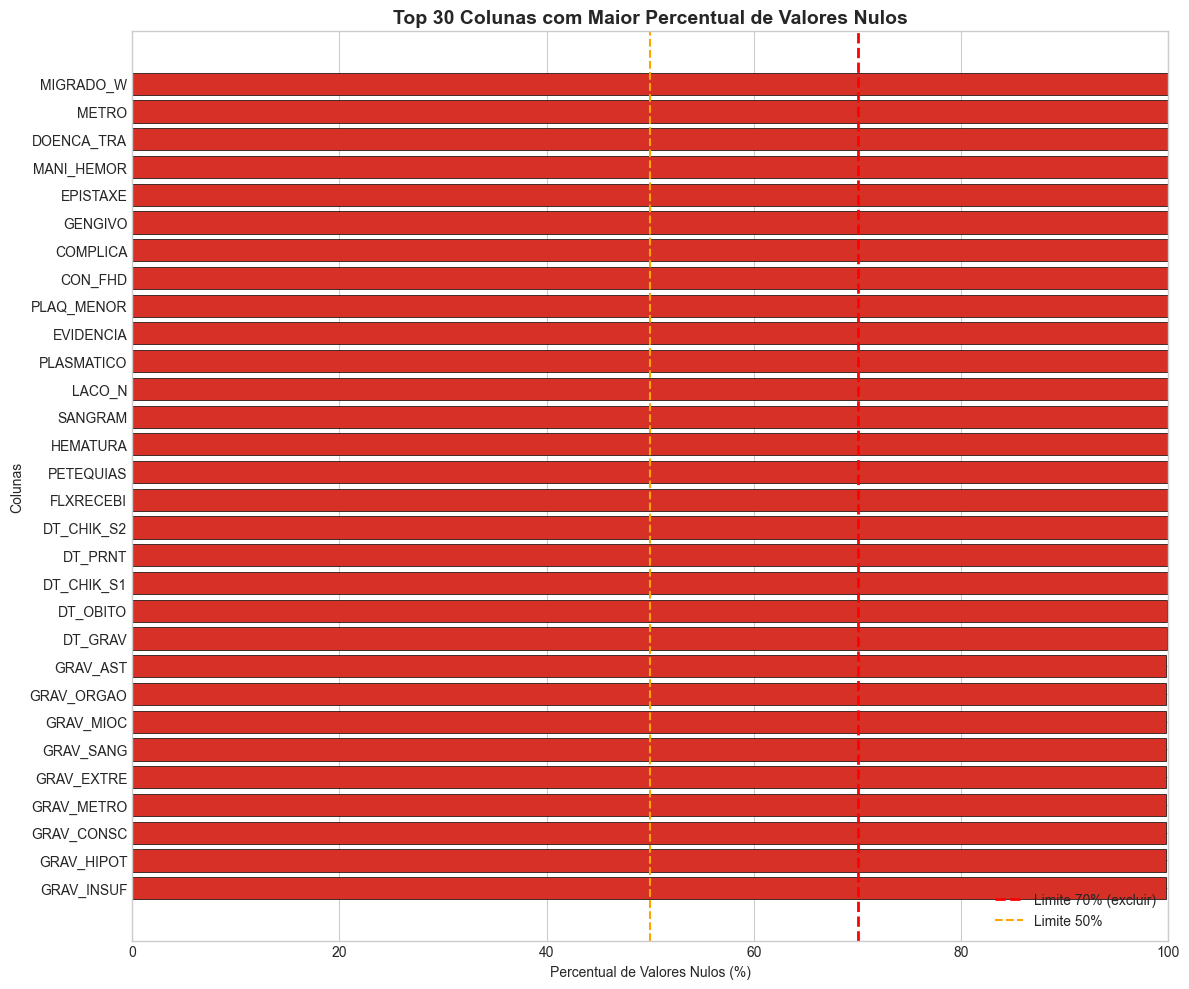

In [19]:
# Grafico 1: Percentual de Valores Nulos por Coluna (Top 30)
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
top_nulls = null_pct.tail(30)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#d73027' if x > 70 else '#fc8d59' if x > 50 else '#fee08b' if x > 30 else '#91cf60' for x in top_nulls.values]
bars = ax.barh(top_nulls.index, top_nulls.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Limite 70% (excluir)')
ax.axvline(x=50, color='orange', linestyle='--', linewidth=1.5, label='Limite 50%')
ax.set_xlabel('Percentual de Valores Nulos (%)')
ax.set_ylabel('Colunas')
ax.set_title('Top 30 Colunas com Maior Percentual de Valores Nulos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

In [20]:
# Preparacao dos dados - converter datas e criar colunas auxiliares
colunas_data = ['DT_NOTIFIC', 'DT_SIN_PRI', 'DT_INVEST', 'DT_INTERNA', 'DT_OBITO', 'DT_ENCERRA']
for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Criar coluna com nome do estado a partir do codigo SG_UF_NOT
if 'SG_UF_NOT' in df.columns:
    df['UF_NOME'] = df['SG_UF_NOT'].apply(get_uf_name)

# Criar coluna com nome do estado a partir do codigo do municipio (ID_REGIONA)
if 'ID_REGIONA' in df.columns:
    df['UF_REGIAO'] = df['ID_REGIONA'].apply(get_uf_from_municipio)
    df['UF_REGIAO_NOME'] = df['UF_REGIAO'].apply(get_uf_name)

# Criar coluna de mes
if 'DT_NOTIFIC' in df.columns:
    df['MES_NOTIFIC'] = df['DT_NOTIFIC'].dt.month
    df['ANO_MES'] = df['DT_NOTIFIC'].dt.to_period('M')

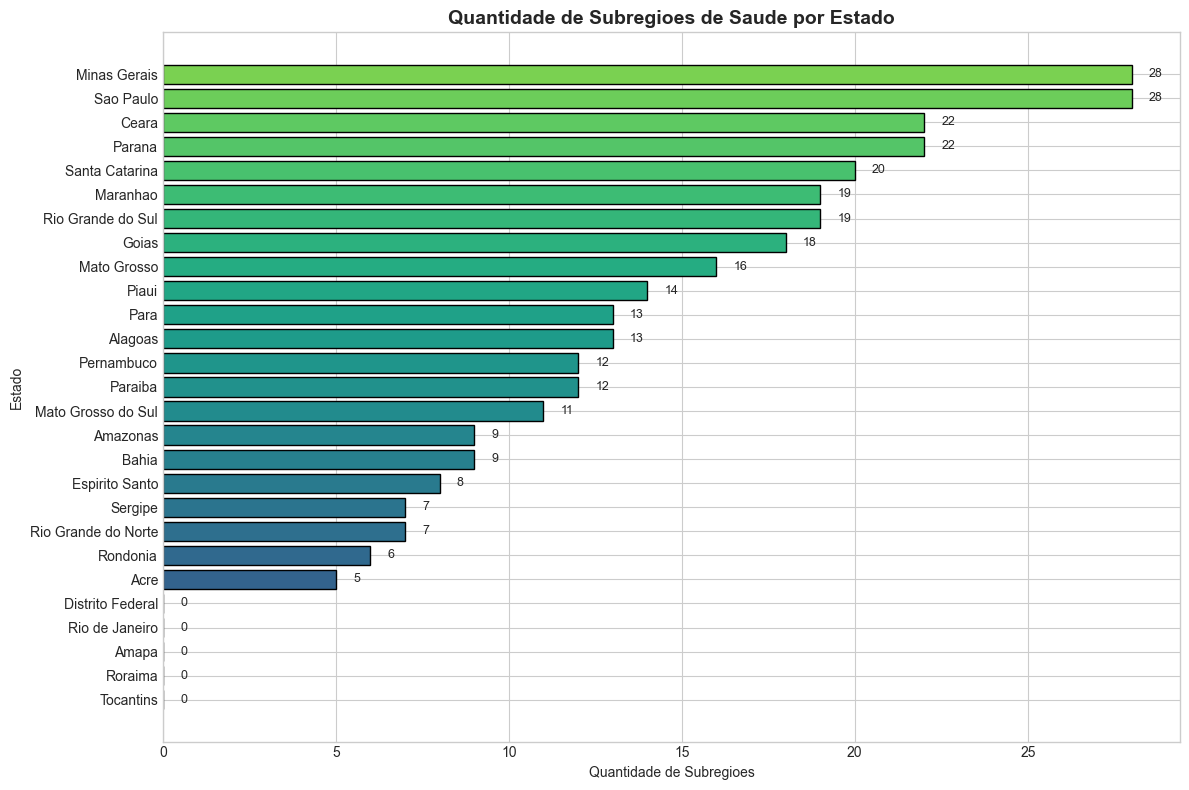

In [21]:
# Grafico 2: Quantidade de Subregioes por Estado
if 'ID_REGIONA' in df.columns and 'UF_NOME' in df.columns:
    subregioes_por_uf = df.groupby('UF_NOME')['ID_REGIONA'].nunique().sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(subregioes_por_uf)))
    bars = ax.barh(subregioes_por_uf.index, subregioes_por_uf.values, color=colors, edgecolor='black')
    
    for bar, val in zip(bars, subregioes_por_uf.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val}', va='center', fontsize=9)
    
    ax.set_xlabel('Quantidade de Subregioes')
    ax.set_ylabel('Estado')
    ax.set_title('Quantidade de Subregioes de Saude por Estado', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

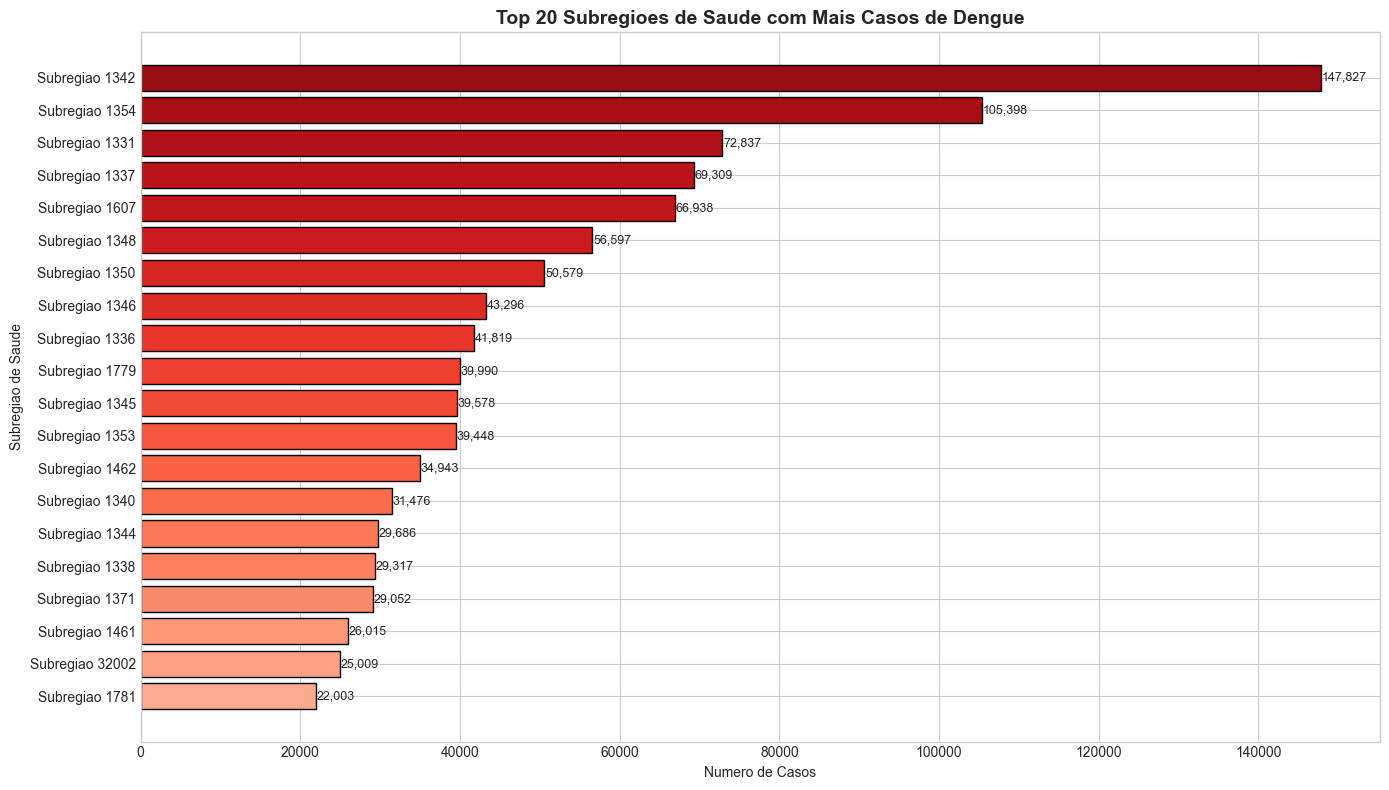

In [22]:
# Grafico 3: Top 20 Subregioes com Mais Casos
if 'ID_REGIONA' in df.columns:
    casos_por_subregiao = df['ID_REGIONA'].value_counts().head(20)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(casos_por_subregiao)))[::-1]
    bars = ax.barh(range(len(casos_por_subregiao)), casos_por_subregiao.values, color=colors, edgecolor='black')
    
    # Adicionar labels com codigo da subregiao
    ax.set_yticks(range(len(casos_por_subregiao)))
    ax.set_yticklabels([f'Subregiao {int(x)}' for x in casos_por_subregiao.index])
    
    for bar, val in zip(bars, casos_por_subregiao.values):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)
    
    ax.set_xlabel('Numero de Casos')
    ax.set_ylabel('Subregiao de Saude')
    ax.set_title('Top 20 Subregioes de Saude com Mais Casos de Dengue', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

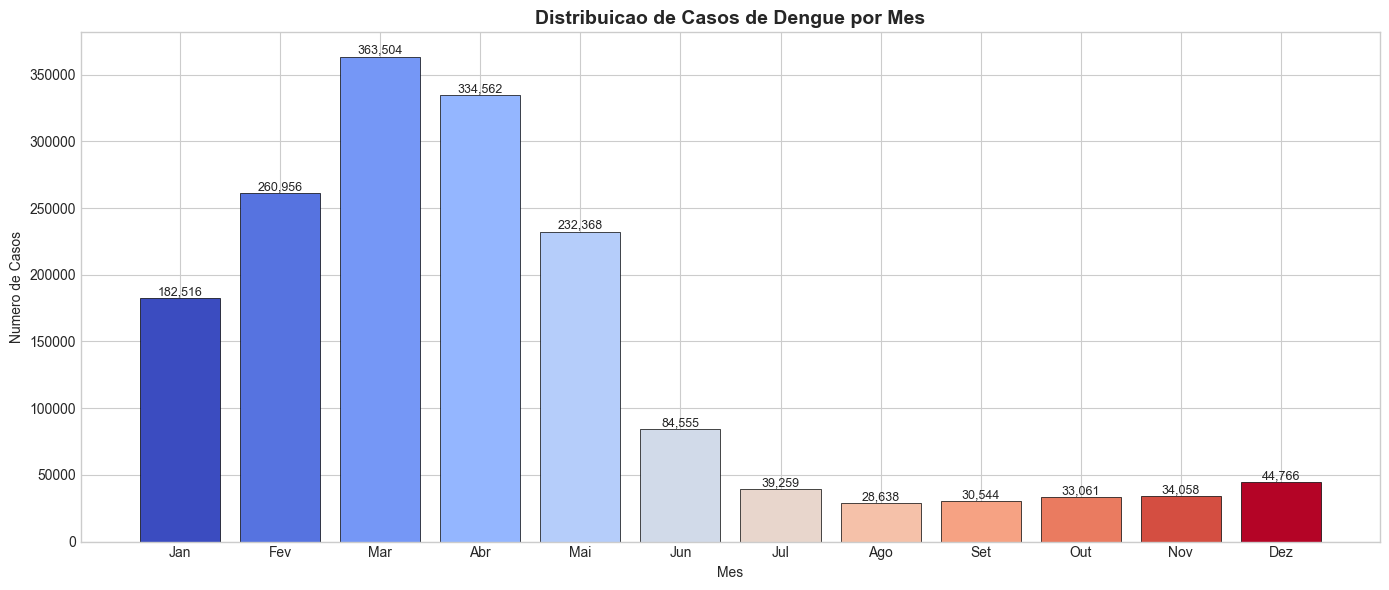

In [23]:
# Grafico 4: Distribuicao de Casos por Mes
if 'MES_NOTIFIC' in df.columns:
    casos_por_mes = df['MES_NOTIFIC'].value_counts().sort_index()
    meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.coolwarm(np.linspace(0, 1, 12))
    bars = ax.bar(range(1, 13), [casos_por_mes.get(i, 0) for i in range(1, 13)], 
                  color=colors, edgecolor='black', linewidth=0.5)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9, rotation=0)
    
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Numero de Casos')
    ax.set_title('Distribuicao de Casos de Dengue por Mes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Grafico 5: Distribuicao de Casos por Estado
if 'UF_NOME' in df.columns:
    casos_por_uf = df['UF_NOME'].value_counts().sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(casos_por_uf)))
    bars = ax.barh(casos_por_uf.index, casos_por_uf.values, color=colors, edgecolor='black')
    
    for bar, val in zip(bars, casos_por_uf.values):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=8)
    
    ax.set_xlabel('Numero de Casos')
    ax.set_ylabel('Estado')
    ax.set_title('Distribuicao de Casos de Dengue por Estado', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

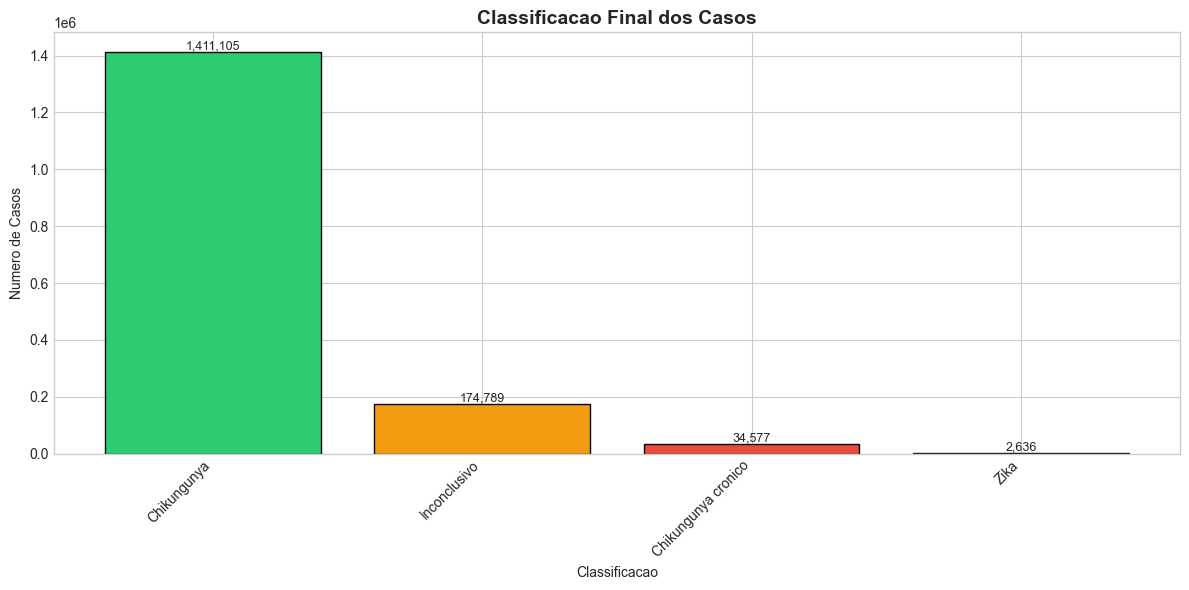

In [24]:
# Grafico 6: Classificacao Final dos Casos
if 'CLASSI_FIN' in df.columns:
    classi_map = {
        1: 'Dengue', 2: 'Dengue c/ sinais alarme', 3: 'Dengue grave',
        5: 'Descartado', 8: 'Inconclusivo', 10: 'Chikungunya',
        11: 'Chikungunya cronico', 12: 'Zika', 13: 'Obito investigacao'
    }
    df['CLASSI_FIN_LABEL'] = df['CLASSI_FIN'].map(classi_map)
    
    classificacao = df['CLASSI_FIN_LABEL'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6', '#3498db', '#9b59b6', '#1abc9c', '#e91e63', '#34495e']
    bars = ax.bar(range(len(classificacao)), classificacao.values, color=colors[:len(classificacao)], edgecolor='black')
    
    ax.set_xticks(range(len(classificacao)))
    ax.set_xticklabels(classificacao.index, rotation=45, ha='right')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Classificacao')
    ax.set_ylabel('Numero de Casos')
    ax.set_title('Classificacao Final dos Casos', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()